# 이상 탐지를 위한 오토인코더 학습하기

### 문제 설명
이상 탐지를 위한 **오토인코더** 모델을 구현합니다. 이 모델은 **MNIST 데이터셋**으로 학습되며, 재구성 오차를 바탕으로 이상을 탐지합니다. 오토인코더는 입력을 압축하는 encoder와 이미지를 다시 복원하는 decoder로 구성됩니다. 원본 이미지와 복원된 이미지의 차이를 사용해 이상 여부를 판별합니다.

### 요구사항
1. **오토인코더 구조 정의**:
   - **Encoder**:
     - 일련의 합성곱 레이어와 max-pooling 레이어를 구현합니다.
     - Encoder는 입력 이미지의 공간 차원을 점진적으로 줄이면서 가장 중요한 특징을 포착해야 합니다.
   - **Decoder**:
     - 압축된 표현을 원래 이미지 크기로 다시 업샘플링하기 위해 일련의 transposed convolution 레이어(또는 deconvolution 레이어)를 구현합니다.
     - 최종 레이어에는 **Sigmoid 활성화** 함수를 사용해 출력 픽셀 값이 0과 1 사이가 되도록 합니다.

2. **Forward Pass**:
   - 입력 이미지를 encoder에 통과시켜 압축된 표현을 얻은 뒤, decoder에 전달해 이미지를 복원하는 forward 메서드를 구현합니다.

### 제약 사항
- 오토인코더는 28x28 그레이스케일 이미지로 구성된 MNIST 데이터셋에서 동작해야 합니다.
- decoder의 출력이 원본 이미지 크기와 일치해야 합니다.
- 최종 레이어에 **Sigmoid 활성화**를 사용해 출력 픽셀 값이 0과 1 사이로 제한되도록 하세요.

<details>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [13]:
x = next(iter(train_loader)) # train_loader
x[0].shape

torch.Size([64, 1, 28, 28])

In [ ]:
# Define an Autoencoder model
# TODO: Implement the autoencoder architecture
class Autoencoder(nn.Module):
    def __init__(self):
        # init
        super(Autoencoder, self).__init__()
        self.activation = nn.ReLU()
        # Encoder
        self.encoder = nn.Sequential( # 모험정신은 좋다! CNN 오토인코더로 가볼거다.
            nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size=2, stride = 2), # 이미지의 가로, 세로가 절반으로 줄어든다. 32 x 14 x 14 차원.
            self.activation,
            nn.Conv2d(in_channels = 32, out_channels=64, kernel_size=2, stride=2),
            self.activation,
            nn.Conv2d(in_channels = 64, out_channels=128, kernel_size=2, stride=2),
            self.activation,
        )   
        self.compress = nn.Linear(128*3*3, 10)
        self.decompress = nn.Linear(10, 128*3*3) # view를 활용해 다시 128, 3, 3으로 돌려야 함.
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2, output_padding=1), # Conv2d의 floor로 인해서, output_padding 없이는 64, 6, 6이 되어버립니다. 이를 해결하기 위해서 output_padding=1로 해주면 7이 됨
            self.activation,
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=2, stride=2),
            self.activation,
            nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=2, stride=2)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = torch.flatten(x, start_dim=1, end_dim=3) # 첫번째 인덱스를 기준으로 풀어내야 합니다(0번은 배치 수)
        x = self.compress(x)
        x = self.decompress(x)
        x = x.view(x.shape[0], 128, 3, 3) # 다시 이미지의 형태로 돌려두기
        x = self.decoder(x)
        return x

# Initialize the model, loss function, and optimizer
model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [27]:
# Training loop
epochs = 10
for epoch in range(epochs):
    for images, _ in train_loader:
        # Forward pass
        reconstructed = model(images)
        loss = criterion(reconstructed, images)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [1/10], Loss: 0.1408
Epoch [2/10], Loss: 0.1385
Epoch [3/10], Loss: 0.1350
Epoch [4/10], Loss: 0.1385
Epoch [5/10], Loss: 0.1559
Epoch [6/10], Loss: 0.1335
Epoch [7/10], Loss: 0.1265
Epoch [8/10], Loss: 0.1371
Epoch [9/10], Loss: 0.1349
Epoch [10/10], Loss: 0.1466


In [28]:
# Detect anomalies using reconstruction error
threshold = 0.1  # Define a threshold for anomaly detection
model.eval()
anomalies = []
with torch.no_grad():
    for images, _ in test_loader:
        reconstructed = model(images)
        loss = criterion(reconstructed, images)
        
        # If reconstruction error exceeds the threshold, mark it as an anomaly
        if loss.item() > threshold:
            anomalies.append(images)

Anomaly image shape: torch.Size([28, 28])


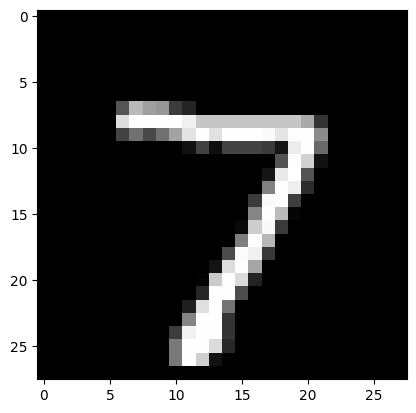

In [29]:
# Visualize anomalies
if anomalies:
    # Select the first anomaly and remove the channel dimension for visualization
    anomaly_image = anomalies[0][0].squeeze()  # Remove the channel dimension (1)
    print(f"Anomaly image shape: {anomaly_image.shape}")  # Optional: Check the shape of the image
    plt.imshow(anomaly_image.cpu().numpy(), cmap='gray')  # Convert tensor to NumPy array for visualization
    plt.show()
else:
    print("No anomalies detected.")
